# SPH in Beltrami force field

In this tutorial, you will set up and run a pressure-less SPH example in Struphy, then inspect particle evolution with simple diagnostics.

This notebook focuses on pressure-less flow in a Beltrami force field (model `PressureLessSPH`). If you want to start from template parameter files, generate them from the command line:

```
struphy params PressureLessSPH
```

The notebook keeps everything in Python so you can adjust parameters interactively and rerun sections quickly.

## Pressure-Less Flow in a Beltrami Force Field

We begin with a particle system in a 3D box domain $\Omega \subset \mathbb{R}^3$.

Given an initial velocity field $\mathbf{u}_0(\mathbf{x})$, we seek trajectories $(\mathbf{x}_p, \mathbf{v}_p)$ for particles $p=0,\dots,N-1$ satisfying

$$
\begin{aligned}
 \dot{\mathbf x}_p &= \mathbf v_p\,,\qquad && \mathbf x_p(0) = \mathbf x_{p0}\,,
 \\[2mm]
 \dot{\mathbf v}_p &= -\nabla p(\mathbf x_p)\,,\qquad && \mathbf v_p(0) = \mathbf u_0(\mathbf x_p(0))\,.
\end{aligned}
$$

Here, $p \in H^1(\Omega)$ is a prescribed scalar field. In this example, we choose $p$ so that the force field has Beltrami structure.

In practice, the workflow is: import APIs, define geometry and time stepping, set marker loading, configure propagators, run, and visualize.

First, import the Struphy components used throughout this tutorial.

In [1]:
from struphy import EnvironmentOptions, Time
from struphy import domains
from struphy import equils
from struphy import grids
from struphy import DerhamOptions
from struphy import (
    BoundaryParameters,
    LoadingParameters,
    WeightsParameters,
    SortingParameters,
    SavingParameters,
)
from struphy import Simulation

### Step 1: Create Environment, Time Integrator, and Domain

Set up a Cartesian (cuboid) domain and use Strang splitting for time integration. These choices define the simulation skeleton before any particle data are attached.

In [2]:
# environment options
env = EnvironmentOptions()

# time stepping
time_opts = Time(dt=0.02, Tend=4, split_algo="Strang")

# geometry
l1 = -0.5
r1 = 0.5
l2 = -0.5
r2 = 0.5
l3 = 0.0
r3 = 1.0
domain = domains.Cuboid(l1=l1, r1=r1, l2=l2, r2=r2, l3=l3, r3=r3)

### Step 2: Define the Beltrami Background

Next, define velocity, pressure, and density functions for the background equilibrium. We pass these to `GenericCartesianFluidEquilibrium`, which will later be used to initialize the particle state.

In [3]:
# construct Beltrami flow
import numpy as np

def u_fun(x, y, z):
    ux = -np.cos(np.pi * x) * np.sin(np.pi * y)
    uy = np.sin(np.pi * x) * np.cos(np.pi * y)
    uz = 0 * x
    return ux, uy, uz

p_fun = lambda x, y, z: 0.5 * (np.sin(np.pi * x) ** 2 + np.sin(np.pi * y) ** 2)
n_fun = lambda x, y, z: 1.0 + 0 * x

# put the functions in a generic equilibrium container
bel_flow = equils.GenericCartesianFluidEquilibrium(u_xyz=u_fun, p_xyz=p_fun, n_xyz=n_fun)

### Step 3: Choose Grid and de Rham Options

Even for particle-based dynamics, Struphy uses spline-based projections for some fields. Here we define a tensor-product grid and matching de Rham settings.

In [4]:
# fluid equilibrium (can be used as part of initial conditions)
equil = None

# grid
grid = grids.TensorProductGrid(num_elements=(64, 64, 1))

# derham options
bcs = (("free", "free"), ("free", "free"), None)
derham_opts = DerhamOptions(degree=(3, 3, 1), bcs=bcs)

### Step 4: Instantiate the `PressureLessSPH` Simulation

Create a lightweight model instance and combine it with the environment, domain, and discretization settings from the previous steps.

In [5]:
# import model
from struphy.models import PressureLessSPH

# light-weight model instance
model = PressureLessSPH(epsilon=1.0)

sim = Simulation(model,
                 env=env,
                 time_opts=time_opts,
                 domain=domain,
                 equil=equil,
                 grid=grid,
                 derham_opts=derham_opts,)

/opt/hostedtoolcache/Python/3.10.20/x64/lib/python3.10/site-packages/struphy/models/species.py:198: UserWarning: Override equation parameter self.epsilon =1.0
  warnings.warn(f"Override equation parameter {self.epsilon =}")


### Step 5: Configure Marker Loading and Saving

Now set particle-marker parameters. In this example we:

- load `Np=1000` particles
- keep default weight construction
- apply reflective boundaries in $x,y$ and periodic in $z$
- save all markers via `n_markers=1.0`

We also keep sorting simple with one box per direction for this first run.

In [6]:
loading_params = LoadingParameters(Np=1000)
weights_params = WeightsParameters()
boundary_params = BoundaryParameters(bc=("reflect", "reflect", "periodic"))
sorting_params = SortingParameters(boxes_per_dim=(1, 1, 1))
saving_params = SavingParameters(n_markers=1.0)

model.cold_fluid.set_markers(
    loading_params=loading_params,
    weights_params=weights_params,
    boundary_params=boundary_params,
    sorting_params=sorting_params,
    saving_params=saving_params
)

### Step 6: Set Propagator Options

Configure the particle pushers. The key detail is to pass the Beltrami pressure potential to `push_v`, so the velocity update uses the intended force field.

In [7]:
# propagator options
from struphy import ButcherTableau

butcher = ButcherTableau(algo="forward_euler")
model.propagators.push_eta.options = model.propagators.push_eta.Options(butcher=butcher)

phi = bel_flow.p0
model.propagators.push_v.phi = phi

### Step 7: Apply Initial Conditions

Attach the Beltrami equilibrium as the background state for the cold fluid species. No additional perturbation is added in this tutorial run.

In [8]:
# background, perturbations and initial conditions
model.cold_fluid.var.add_background(bel_flow)

### Step 8: Run, Post-Process, and Visualize

Execute the simulation pipeline in order:

1. `run()` to advance particles in time
2. `pproc()` to build post-processed outputs
3. `load_plotting_data()` to bring diagnostics into memory

Then plot marker trajectories to inspect how the Beltrami-driven flow evolves.

In [9]:
sim.run()


Starting run for model PressureLessSPH ...


Time stepping:   0%|          | 0/200 [00:00<?, ?step/s]

Time stepping:   8%|▊         | 16/200 [00:00<00:01, 152.41step/s]

Time stepping:  16%|█▌        | 32/200 [00:00<00:01, 152.43step/s]

Time stepping:  24%|██▍       | 48/200 [00:00<00:00, 152.79step/s]

...

Time stepping:  80%|████████  | 160/200 [00:01<00:00, 152.84step/s]

Time stepping:  88%|████████▊ | 176/200 [00:01<00:00, 152.78step/s]

Time stepping:  96%|█████████▌| 192/200 [00:01<00:00, 153.00step/s]

Time stepping: 100%|██████████| 200/200 [00:01<00:00, 152.38step/s]


Struphy run finished.


In [10]:
sim.pproc()


Post-processing path /home/runner/work/struphy/struphy/doc/_collections/tutorials/sim_1



No feec fields found in hdf5 file, skipping post-processing of fields.


Evaluation of 1000 marker orbits for cold_fluid


  0%|          | 0/201 [00:00<?, ?it/s]

 12%|█▏        | 24/201 [00:00<00:00, 235.67it/s]

...

 60%|█████▉    | 120/201 [00:00<00:00, 234.30it/s]

 72%|███████▏  | 144/201 [00:00<00:00, 233.94it/s]

 84%|████████▎ | 168/201 [00:00<00:00, 233.83it/s]

 96%|█████████▌| 192/201 [00:00<00:00, 233.95it/s]

100%|██████████| 201/201 [00:00<00:00, 233.88it/s]

In [11]:
sim.load_plotting_data()


Loading post-processed plotting data:


Data path: /home/runner/work/struphy/struphy/doc/_collections/tutorials/sim_1/post_processing



The following data has been loaded:



grids:


self.t_grid.shape =(201,)



self.spline_values:


self.orbits:


    cold_fluid, shape = (201, 1000, 8)
        Number of time points: 201
        Number of particles:   1000
        Number of attributes:  8



self.f:


self.n_sph:


i=0
i=10
i=20
i=30
i=40
i=50
i=60


i=70
i=80
i=90


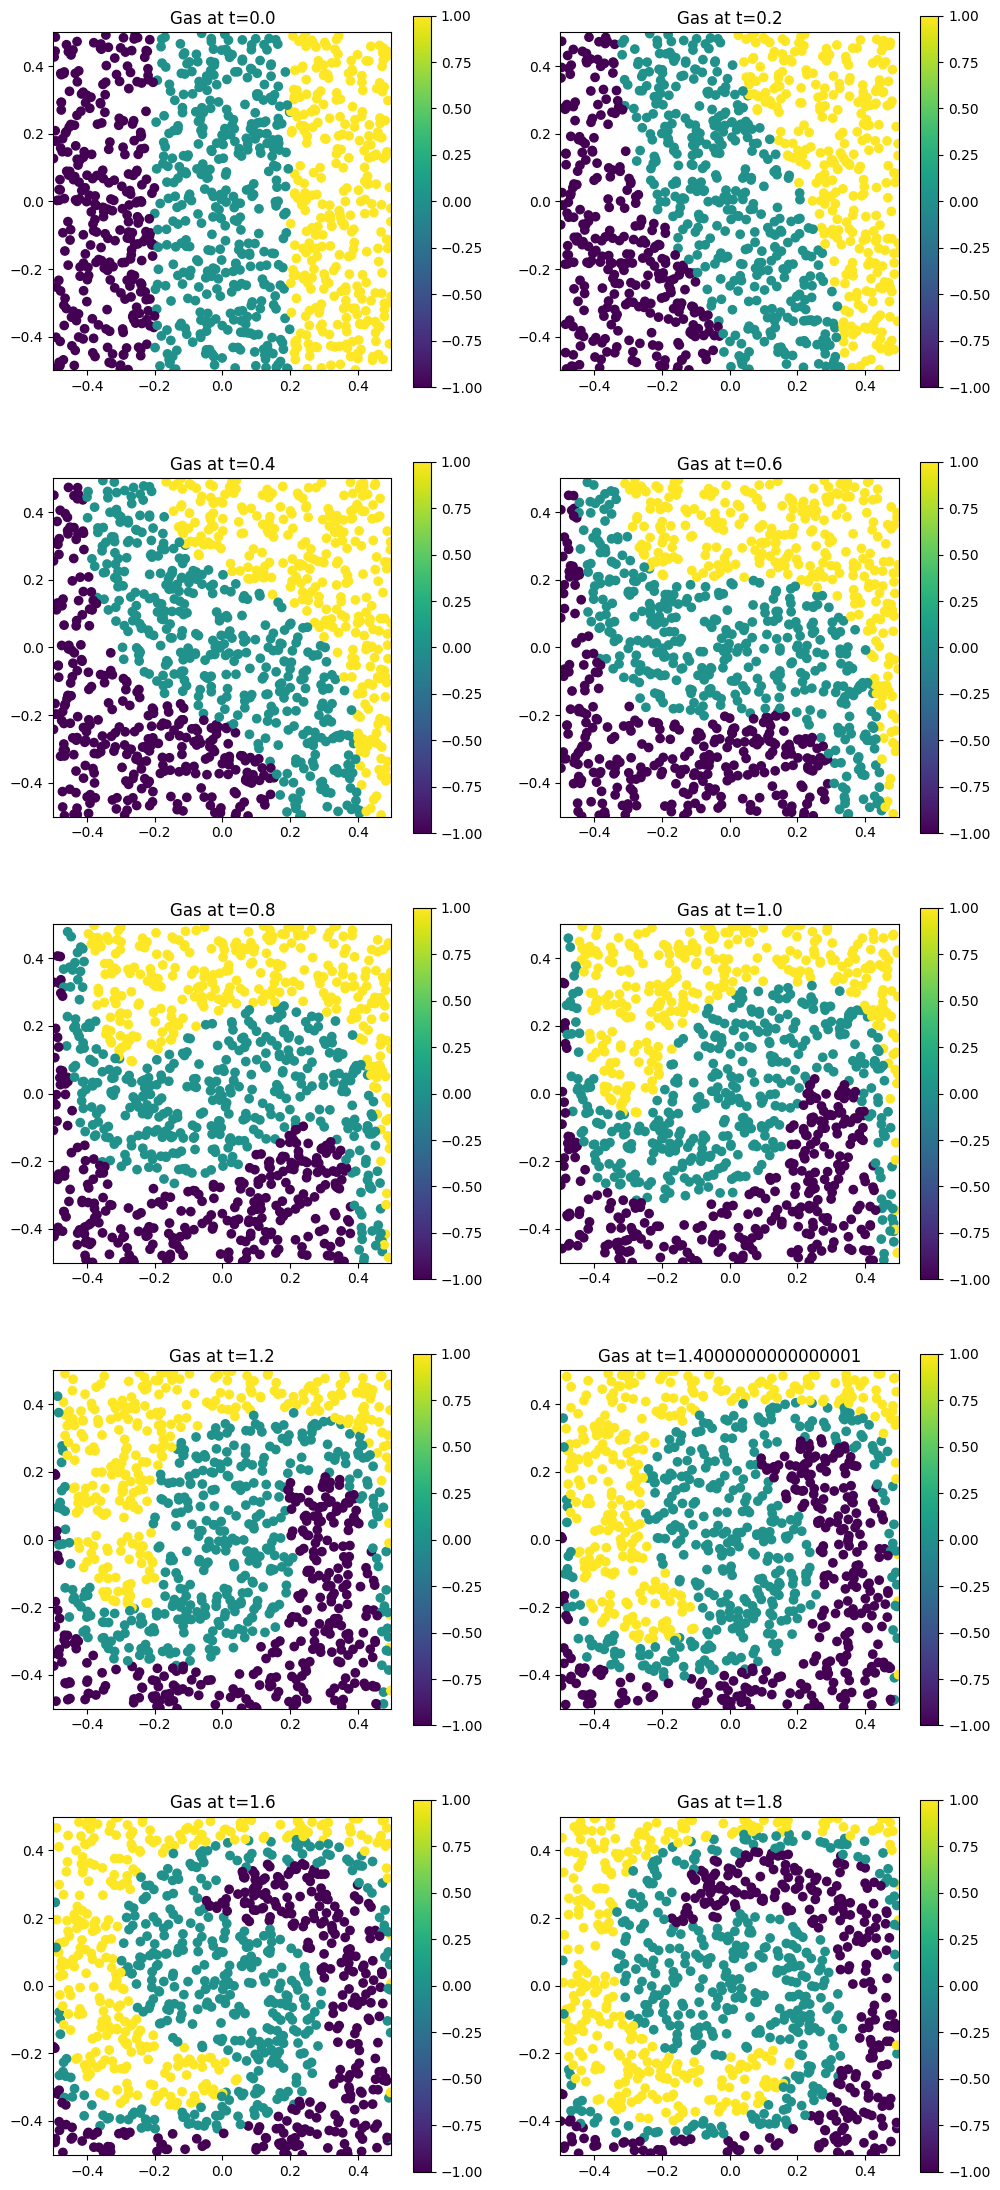

In [12]:
from matplotlib import pyplot as plt

plt.figure(figsize=(12, 28))

orbits = sim.orbits.cold_fluid

coloring = np.select(
    [orbits[0, :, 0] <= -0.2, np.abs(orbits[0, :, 0]) < +0.2, orbits[0, :, 0] >= 0.2], [-1.0, 0.0, +1.0]
)

dt = time_opts.dt
Nt = sim.t_grid.size - 1
interval = Nt / 20
plot_ct = 0
for i in range(Nt):
    if i % interval == 0:
        print(f"{i=}")
        plot_ct += 1
        plt.subplot(5, 2, plot_ct)
        ax = plt.gca()
        plt.scatter(orbits[i, :, 0], orbits[i, :, 1], c=coloring)
        plt.axis("square")
        plt.title("n0_scatter")
        plt.xlim(l1, r1)
        plt.ylim(l2, r2)
        plt.colorbar()
        plt.title(f"Gas at t={i * dt}")
    if plot_ct == 10:
        break

### Step 9: Repeat with Structured Marker Loading

To compare loading strategies, run a second simulation in a separate folder (`sim_2`) so outputs stay isolated from the first run.

In [13]:
# light-weight model instance
model = PressureLessSPH(epsilon=1.0)

# environment options
env = EnvironmentOptions(sim_folder="sim_2")

# simulation instance
sim_tess = sim.spawn_sister(model=model, env=env)

This time, use tessellation-based loading so markers start on a regular grid-like pattern. This gives a useful contrast to random loading when you inspect the trajectory plots.

In [14]:
loading_params = LoadingParameters(ppb=4, loading="tesselation")
weights_params = WeightsParameters()
boundary_params = BoundaryParameters(bc=("reflect", "reflect", "periodic"))
sorting_params = SortingParameters(boxes_per_dim=(16, 16, 1))
saving_params = SavingParameters(n_markers=1.0)

model.cold_fluid.set_markers(
    loading_params=loading_params, 
    weights_params=weights_params, 
    boundary_params=boundary_params, 
    sorting_params=sorting_params,
    saving_params=saving_params,
    bufsize=0.5
)

In [15]:
# propagator options
from struphy import ButcherTableau

butcher = ButcherTableau(algo="forward_euler")
model.propagators.push_eta.options = model.propagators.push_eta.Options(butcher=butcher)

phi = bel_flow.p0
model.propagators.push_v.phi = phi

In [16]:
# background, perturbations and initial conditions
model.cold_fluid.var.add_background(bel_flow)

In [17]:
sim_tess.run()


Starting run for model PressureLessSPH ...


Time stepping:   0%|          | 0/200 [00:00<?, ?step/s]

Time stepping:   7%|▋         | 14/200 [00:00<00:01, 133.70step/s]

Time stepping:  14%|█▍        | 28/200 [00:00<00:01, 133.15step/s]

Time stepping:  21%|██        | 42/200 [00:00<00:01, 133.92step/s]

...

Time stepping:  84%|████████▍ | 168/200 [00:01<00:00, 132.03step/s]

Time stepping:  91%|█████████ | 182/200 [00:01<00:00, 132.45step/s]

Time stepping:  98%|█████████▊| 196/200 [00:01<00:00, 133.00step/s]

Time stepping: 100%|██████████| 200/200 [00:01<00:00, 132.83step/s]


Struphy run finished.


In [18]:
sim_tess.pproc()


Post-processing path /home/runner/work/struphy/struphy/doc/_collections/tutorials/sim_2



No feec fields found in hdf5 file, skipping post-processing of fields.


Evaluation of 1024 marker orbits for cold_fluid


  0%|          | 0/201 [00:00<?, ?it/s]

 12%|█▏        | 24/201 [00:00<00:00, 234.88it/s]

...

 60%|█████▉    | 120/201 [00:00<00:00, 233.00it/s]

 72%|███████▏  | 144/201 [00:00<00:00, 232.67it/s]

 84%|████████▎ | 168/201 [00:00<00:00, 231.97it/s]

 96%|█████████▌| 192/201 [00:00<00:00, 232.49it/s]

100%|██████████| 201/201 [00:00<00:00, 232.58it/s]

In [19]:
sim_tess.load_plotting_data()


Loading post-processed plotting data:


Data path: /home/runner/work/struphy/struphy/doc/_collections/tutorials/sim_2/post_processing



The following data has been loaded:



grids:


self.t_grid.shape =(201,)



self.spline_values:


self.orbits:


    cold_fluid, shape = (201, 1024, 8)
        Number of time points: 201
        Number of particles:   1024
        Number of attributes:  8



self.f:


self.n_sph:


i=0
i=10
i=20
i=30
i=40
i=50
i=60


i=70
i=80
i=90


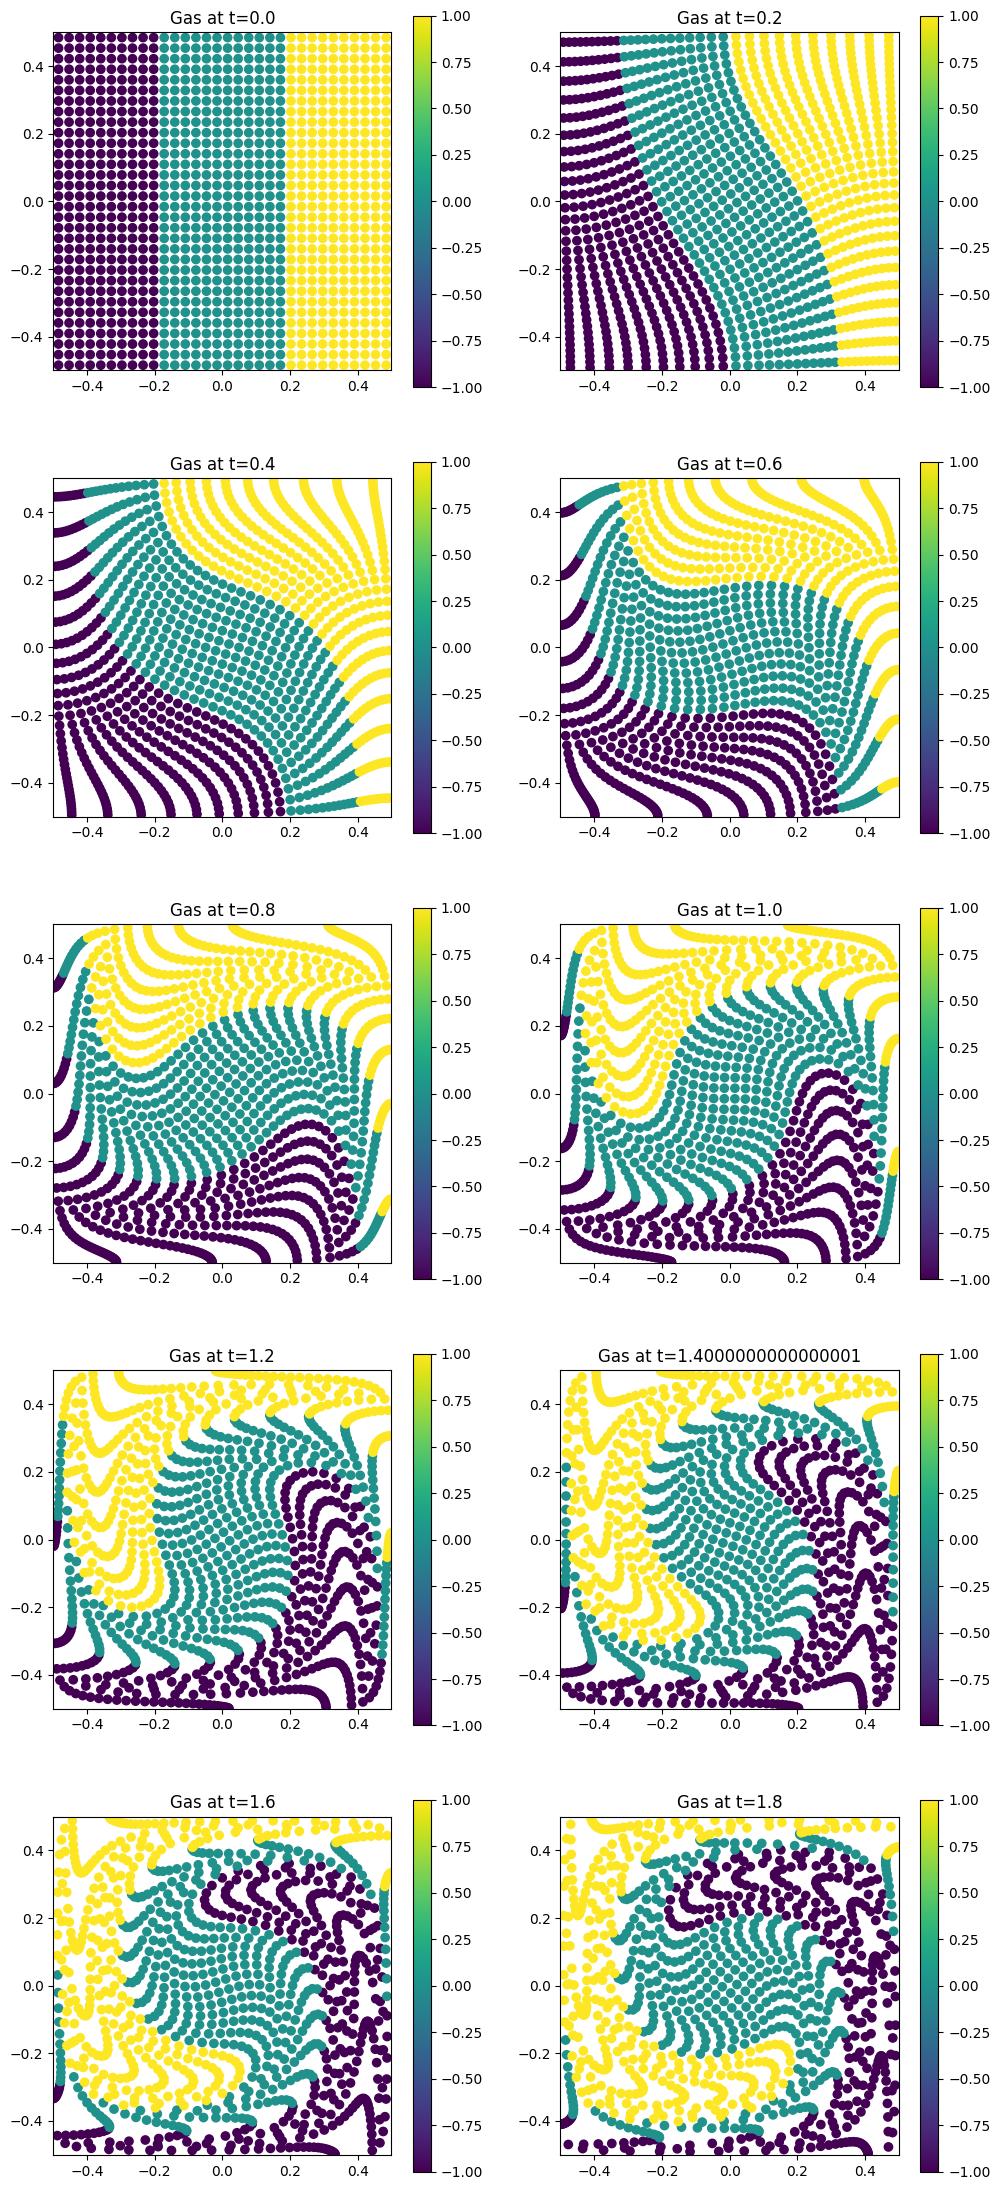

In [20]:
from matplotlib import pyplot as plt

plt.figure(figsize=(12, 28))

orbits = sim_tess.orbits.cold_fluid

coloring = np.select(
    [orbits[0, :, 0] <= -0.2, np.abs(orbits[0, :, 0]) < +0.2, orbits[0, :, 0] >= 0.2], [-1.0, 0.0, +1.0]
)

dt = time_opts.dt
Nt = sim_tess.t_grid.size - 1
interval = Nt / 20
plot_ct = 0
for i in range(Nt):
    if i % interval == 0:
        print(f"{i=}")
        plot_ct += 1
        plt.subplot(5, 2, plot_ct)
        ax = plt.gca()
        plt.scatter(orbits[i, :, 0], orbits[i, :, 1], c=coloring)
        plt.axis("square")
        plt.title("n0_scatter")
        plt.xlim(l1, r1)
        plt.ylim(l2, r2)
        plt.colorbar()
        plt.title(f"Gas at t={i * dt}")
    if plot_ct == 10:
        break